Fitting 5 folds for each of 4 candidates, totalling 20 fits

=== Best Logistic Regression Model ===
Best F1 Score: 0.5078178099849926
Best Parameters: {'classifier__C': 0.01}

=== Evaluation on Full Dataset ===
Accuracy: 0.5
Classification Report:
              precision    recall  f1-score   support

        crop       0.50      0.50      0.50        10
        wild       0.50      0.50      0.50        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.50        20
weighted avg       0.50      0.50      0.50        20



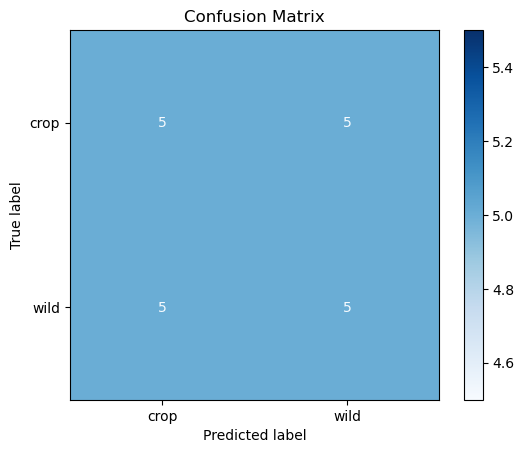

In [11]:
# Single fit

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# === Parameters ===
CSV_FILE = "virus_data.csv"  # Must contain: id, type, family, length, sequence
KMER_SIZES = [3]
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load Data from CSV ===
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACDEFGHIKLMNPQRSTVWY]', '', regex=True)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['type'])

    return df, y, label_encoder

# === Grid Search with Logistic Regression ===
def run_logistic_regression_grid(kmers_train, y_train):
    pipeline = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("classifier", LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE))
    ])

    param_grid = {
        "classifier__C": [0.01]
    }

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(kmers_train, y_train)

    return grid.best_estimator_, grid.best_score_, grid.best_params_

# === Model Evaluation ===
def evaluate_model(model, kmers_test, y_test, label_encoder):
    y_pred = model.predict(kmers_test)

    print("\n=== Evaluation on Test Dataset ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    return y_pred

# === Main Workflow ===
def main():
    df, y, le = load_data(CSV_FILE)

    best_score = -1
    best_model = None
    best_k = None
    best_data = None

    for k in KMER_SIZES:
        print(f"\n=== Trying k-mer size {k} ===")
        df['kmers'] = df['sequence'].apply(lambda s: get_kmers(s, k))
        filtered = df[df['kmers'].str.len() > 0].copy()

        kmers = filtered['kmers']
        ids = filtered['id']
        y_filtered = le.transform(filtered['type'])

        # Split
        kmers_train, kmers_test, y_train, y_test, ids_train, ids_test = train_test_split(
            kmers, y_filtered, filtered['id'], test_size=TEST_SIZE, stratify=y_filtered, random_state=RANDOM_STATE
        )

        model, score, params = run_logistic_regression_grid(kmers_train, y_train)
        print(f"Best F1: {score:.4f} | Params: {params}")

        if score > best_score:
            best_score = score
            best_model = model
            best_k = k
            best_data = (kmers_test, y_test, ids_test)

    print(f"\n=== Best Model: k-mer = {best_k} | F1 = {best_score:.4f} ===")
    kmers_test, y_test, ids_test = best_data

    y_pred = evaluate_model(best_model, kmers_test, y_test, le)

    print("\n=== Misclassified Sequence IDs ===")
    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true != pred:
            print(ids_test.iloc[i])

if __name__ == "__main__":
    main()

Fitting 5 folds for each of 4 candidates, totalling 20 fits

=== Best Logistic Regression Model ===
Best F1 Score: 0.5078178099849926
Best Parameters: {'classifier__C': 0.01}

=== Evaluation on Full Dataset ===
Accuracy: 0.5
Classification Report:
              precision    recall  f1-score   support

        crop       0.50      0.50      0.50        10
        wild       0.50      0.50      0.50        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.50        20
weighted avg       0.50      0.50      0.50        20



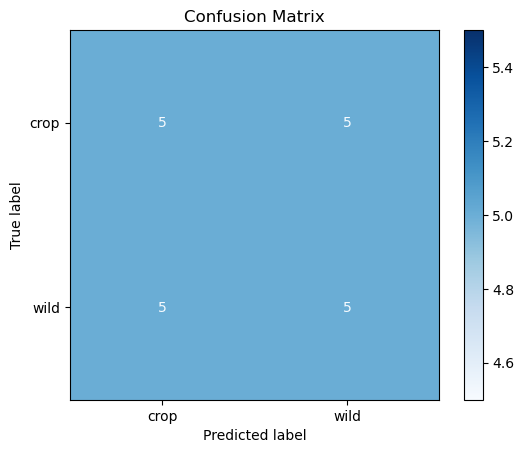

In [11]:
# Hyperparameter tuning

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# === Parameters ===
CSV_FILE = "virus_data.csv"  # Must contain: id, type, family, length, sequence
KMER_SIZES = [3, 5, 7]
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load Data from CSV ===
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACDEFGHIKLMNPQRSTVWY]', '', regex=True)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['type'])

    return df, y, label_encoder

# === Grid Search with Logistic Regression ===
def run_logistic_regression_grid(kmers_train, y_train):
    pipeline = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("classifier", LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE))
    ])

    param_grid = {
        "classifier__C": [0.01, 0.1, 1, 10, 100]
    }

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(kmers_train, y_train)

    return grid.best_estimator_, grid.best_score_, grid.best_params_

# === Model Evaluation ===
def evaluate_model(model, kmers_test, y_test, label_encoder):
    y_pred = model.predict(kmers_test)

    print("\n=== Evaluation on Test Dataset ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    return y_pred

# === Main Workflow ===
def main():
    df, y, le = load_data(CSV_FILE)

    best_score = -1
    best_model = None
    best_k = None
    best_data = None

    for k in KMER_SIZES:
        print(f"\n=== Trying k-mer size {k} ===")
        df['kmers'] = df['sequence'].apply(lambda s: get_kmers(s, k))
        filtered = df[df['kmers'].str.len() > 0].copy()

        kmers = filtered['kmers']
        ids = filtered['id']
        y_filtered = le.transform(filtered['type'])

        # Split
        kmers_train, kmers_test, y_train, y_test, ids_train, ids_test = train_test_split(
            kmers, y_filtered, filtered['id'], test_size=TEST_SIZE, stratify=y_filtered, random_state=RANDOM_STATE
        )

        model, score, params = run_logistic_regression_grid(kmers_train, y_train)
        print(f"Best F1: {score:.4f} | Params: {params}")

        if score > best_score:
            best_score = score
            best_model = model
            best_k = k
            best_data = (kmers_test, y_test, ids_test)

    print(f"\n=== Best Model: k-mer = {best_k} | F1 = {best_score:.4f} ===")
    kmers_test, y_test, ids_test = best_data

    y_pred = evaluate_model(best_model, kmers_test, y_test, le)

    print("\n=== Misclassified Sequence IDs ===")
    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true != pred:
            print(ids_test.iloc[i])

if __name__ == "__main__":
    main()